# DocTalk Chat Corpus Analyse Direktnachrichten
Autorin: Sabine Sayegh-Jodehl <br>

Version 1.0 Ausweitung der eingeschlossenen Gespräche (Direktnachrichten)

Python 3.11.9 (Windows)
____________________________________________________________

# Allgemeine Vorbereitungen

In [1]:
import os
from pathlib import Path

# Verzeichnis setzen
arbeitsverzeichnis = Path(
    r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten")

# Setzen des Arbeitsverzeichnisses
os.chdir(arbeitsverzeichnis)

# Konvertierung des Arbeitsverzeichnisses in einen Zeichenfolgepfad
corpus_directory_path = str(arbeitsverzeichnis)

# Überprüfen des aktuellen Arbeitsverzeichnisses, um sicherzustellen, dass es geändert wurde
print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

# Verwendung von corpus_directory_path als einfacher Zeichenfolgepfad
print("corpus_directory_path:", corpus_directory_path)

Aktuelles Arbeitsverzeichnis: c:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten
corpus_directory_path: C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten


In [2]:
# Bildauflösung anpassen

%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import convokit
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import wordcloud as wc
import os
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sayeghjs\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# Corpus laden

Ausgangskorpus <br>
tokenisiert und lemmatisiert <br>

"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_tok"


In [5]:
from convokit import Corpus, Speaker, Utterance 

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Utterances mit Fragewörtern

**Fragewörter definieren**<br>
Zu den typischen Fragewörtern gehören: <br>

W-Fragen: wer, was, wann, wo, warum, wie, welchen, welche, welches<br>
Höfliche Fragen: könnte, dürfte, würde, ist es möglich

**Schritte zur Extraktion**<br>
Fragewörterliste erstellen: Eine Liste der Fragewörter, die im Corpus gesucht werden sollen.<br>
Textdurchlauf: Suche nach Sätzen oder Äußerungen, die mindestens eines dieser Fragewörter enthalten.<br>
Punktuation: Optionale Überprüfung, ob der Satz mit einem Fragezeichen ? endet.<br>
Speichern: Die gefundenen Fragen können in einer Liste oder Datei gespeichert werden.

In [5]:
from convokit import Corpus
import re

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Liste der Fragewörter
fragewoerter = [
    r'\bwer\b', r'\bwas\b', r'\bwann\b', r'\bwo\b', r'\bwarum\b', r'\bwie\b',
    r'\bwelchen\b', r'\bwelche\b', r'\bwelches\b', r'\bkönnte\b', r'\bdürfte\b',
    r'\bwürde\b', r'\bist es möglich\b'
]

# Regex für Fragen
frage_regex = re.compile(r'|'.join(fragewoerter), re.IGNORECASE)



# Extrahieren der Äußerungen, die eine Frage enthalten
fragen = []
for utterance in corpus.iter_utterances():
    text = utterance.text
    if frage_regex.search(text):
        fragen.append((utterance.id, text))  # ID und Text speichern

# Ausgabe
print("Gefundene Fragen:")
for id_, frage in fragen:
    print(f"ID: {id_}, Frage: {frage}")

Gefundene Fragen:
ID: 0, Frage: Hallo  Ich wollte dich kurz vorwarnen  dass es evtl zu Konflikten zw den  en in Zimmer 5 kommen könnte aufgrund der Religionsunterschiede   PatName  hat sich gerade darüber aufgeregt dass   PatName  im Zimmer betet bis jetzt geht er immer raus wenn es dazu kommt aber es hat Konfliktpotential
ID: 2, Frage: Hallo  Vorname das Troponin von  PatName  liegt wieder bei 33 also mehr oder weniger idem zur aufnahme dann leiten wir vorerst keine weiteren schritte ein oder? würde das ganze heute abend den gastros jedoch übergeben  damit sie bescheid wissen
ID: 4, Frage: liebe  Vorname kannst du mir vielleicht nochmal verraten wer für unsere PhysmedKonsile macht?
ID: 13, Frage: hi  Vorname unsere neuaufnahme von gestern frau  PatName  berichtet von zunehmendem gedächtnisverlust Sie habe wohl auch einmalig ihren sohn nicht erkannt Dachte vielleicht könnte eine der praktikantinnen einen MiniMental Test oder ähnliches mit ihr machen?
ID: 14, Frage: hey  Vorname danke f

In [4]:
import pandas as pd
import re
from collections import Counter
from convokit import Corpus

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Liste der Fragewörter
fragewoerter = [
    r'\bwer\b', r'\bwas\b', r'\bwann\b', r'\bwo\b', r'\bwarum\b', r'\bwie\b',
    r'\bwelchen\b', r'\bwelche\b', r'\bwelches\b', r'\bkönnte\b', r'\bdürfte\b',
    r'\bwürde\b', r'\bist es möglich\b'
]

# Combine regex patterns for Fragewörter
fragewoerter_regex = re.compile(r'|'.join(fragewoerter), re.IGNORECASE)

# Counter für alle Fragewörter
fragewort_counter = Counter()

# Durchlaufe alle Utterances und zähle die Fragewörter
for utterance in corpus.iter_utterances():
    text = utterance.text.lower()
    matches = fragewoerter_regex.findall(text)
    fragewort_counter.update(matches)

# Ergebnisse in einen DataFrame umwandeln
fragewort_df = pd.DataFrame(fragewort_counter.items(), columns=[
                            "Fragewort", "Anzahl"])

# Sortieren nach Häufigkeit
fragewort_df = fragewort_df.sort_values(by="Anzahl", ascending=False)

# Speichern als CSV-Datei
csv_path = "fragewoerter_counts.csv"
fragewort_df.to_csv(csv_path, index=False)

# Ausgabe zur Kontrolle
print(fragewort_df)

   Fragewort  Anzahl
1      würde     250
4        was     243
3        wie     238
0     könnte     111
8       wann      82
6         wo      43
7     welche      31
2        wer      27
5      warum      18
11   welchen      10
9    welches       7
10    dürfte       2


In [6]:
import pandas as pd
import re
from convokit import Corpus

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Liste der Fragewörter
fragewoerter = [
    r'\bwer\b', r'\bwas\b', r'\bwann\b', r'\bwo\b', r'\bwarum\b', r'\bwie\b',
    r'\bwelchen\b', r'\bwelche\b', r'\bwelches\b', r'\bkönnte\b', r'\bdürfte\b',
    r'\bwürde\b', r'\bist es möglich\b'
]

# Liste für Ergebnisse
examples_list = []

# Maximal 10 Beispiele pro Fragewort sammeln
max_examples = 10

# Sammele Beispiele für jedes Fragewort
for fragewort in fragewoerter:
    # Entferne Regex-Symbole für die Darstellung
    fragewort_cleaned = fragewort.strip(r'\b')
    examples = [
        utterance.text for utterance in corpus.iter_utterances()
        if re.search(fragewort, utterance.text, re.IGNORECASE)
    ][:max_examples]  # Nimm maximal 10 Beispiele
    for example in examples:
        examples_list.append(
            {"Fragewort": fragewort_cleaned, "Beispiel": example})

# Konvertiere die Liste in einen DataFrame
fragewort_examples = pd.DataFrame(examples_list)

# Sortieren nach Fragewort für Übersichtlichkeit
fragewort_examples = fragewort_examples.sort_values(
    by="Fragewort").reset_index(drop=True)

# Speichern als CSV-Datei
csv_path = "fragewort_examples.csv"
fragewort_examples.to_csv(csv_path, index=False)

# DataFrame ausgeben
print(fragewort_examples.head(20))

   Fragewort                                           Beispiel
0     dürfte  Hi  Vorname sorry war in der Gruppe Ja das dür...
1     dürfte   PatName  hätte noch ein paar fragen zu ihrem ...
2     könnte  hey  Vorname danke für Deine information und ü...
3     könnte  Eine andere Frage  diesen Freitag findet wiede...
4     könnte  Liebe  Vorname ich hoffe du kommst gut aus dem...
5     könnte  Ich habe auch Spätdienst und dann könnte ich n...
6     könnte  Hallo  Ich wollte dich kurz vorwarnen  dass es...
7     könnte                              14 Uhr könnte klappen
8     könnte  Und   PatName  braucht iv Kalium und Phosphat ...
9     könnte  Tiefgründige PT ist das nicht Er macht nämlich...
10    könnte  hi  Vorname unsere neuaufnahme von gestern fra...
11    könnte  Suchtkriterien Wobei nach DSM5 sind die Kriter...
12      wann    Wann kannst du   PatName  Neuaufnahme begrüßen?
13      wann  habe eben vergessen dir noch zu  PatName  Rück...
14      wann  wann hättest du zeit die n

In [42]:
import pandas as pd

# Gruppieren und sicherstellen, dass leere Gruppen ausgeschlossen werden
pivot_data = fragewort_examples.groupby(
    "Fragewort")["Beispiel"].apply(list).reset_index()

# Maximale Anzahl von Beispielen pro Fragewort
if not pivot_data.empty:
    max_rows = max(pivot_data["Beispiel"].apply(len))
else:
    max_rows = 0

# Überprüfung, ob Daten vorhanden sind
if max_rows > 0:
    # Die Liste der Beispiele in Spalten umwandeln
    expanded_data = pd.DataFrame({
        fragewort: examples + [None] *
        (max_rows - len(examples))  # Auffüllen mit None
        for fragewort, examples in zip(pivot_data["Fragewort"], pivot_data["Beispiel"])
    })

    # Speichern als CSV-Datei
    csv_path_pivoted = "fragewort_examples_pivoted.csv"
    expanded_data.to_csv(csv_path_pivoted, index=False)

    # Ausgabe zur Kontrolle
    print(expanded_data.head())
else:
    print("Keine Daten vorhanden, um die Pivot-Tabelle zu erstellen.")

                                              dürfte  \
0  Hi  Vorname sorry war in der Gruppe Ja das dür...   
1   PatName  hätte noch ein paar fragen zu ihrem ...   
2                                               None   
3                                               None   
4                                               None   

                                              könnte  \
0  hey  Vorname danke für Deine information und ü...   
1  Eine andere Frage  diesen Freitag findet wiede...   
2  Liebe  Vorname ich hoffe du kommst gut aus dem...   
3  Ich habe auch Spätdienst und dann könnte ich n...   
4  Hallo  Ich wollte dich kurz vorwarnen  dass es...   

                                                wann  \
0    Wann kannst du   PatName  Neuaufnahme begrüßen?   
1  habe eben vergessen dir noch zu  PatName  Rück...   
2  wann hättest du zeit die neuaufnahme zu bespre...   
3  Wann wollen wir denn die Aufnahmen besprechen?...   
4  Liebe  Vorname   PatName  die kommende Woch

In [1]:
import pandas as pd
import re
from convokit import Corpus

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Liste der Fragewörter
fragewoerter = [
    r'\bwer\b', r'\bwas\b', r'\bwann\b', r'\bwo\b', r'\bwarum\b', r'\bwie\b',
    r'\bwelchen\b', r'\bwelche\b', r'\bwelches\b', r'\bkönnte\b', r'\bdürfte\b',
    r'\bwürde\b', r'\bist es möglich\b'
]

# Combine regex patterns for Fragewörter
fragewoerter_regex = re.compile(r'|'.join(fragewoerter), re.IGNORECASE)

# Liste für Ergebnisse
filtered_examples = []

# Maximal 10 Beispiele pro Fragewort sammeln
max_examples = 20

# Sammele Beispiele für jedes Fragewort, die mit einem Fragezeichen enden
for fragewort in fragewoerter:
    # Entferne Regex-Symbole für die Darstellung
    fragewort_cleaned = fragewort.strip(r'\b')
    examples = [
        utterance.text for utterance in corpus.iter_utterances()
        if re.search(fragewort, utterance.text, re.IGNORECASE) and utterance.text.strip().endswith("?")
    ][:max_examples]  # Nimm maximal 10 Beispiele
    for example in examples:
        filtered_examples.append(
            {"Fragewort": fragewort_cleaned, "Beispiel": example})

# Konvertiere die Liste in einen DataFrame
fragewort_filtered_df = pd.DataFrame(filtered_examples)

# Sortieren nach Fragewort für Übersichtlichkeit
fragewort_filtered_df = fragewort_filtered_df.sort_values(
    by="Fragewort").reset_index(drop=True)

# Speichern als CSV-Datei
csv_path_filtered = "fragewort_filtered_examples.csv"
fragewort_filtered_df.to_csv(csv_path_filtered, index=False, encoding="utf-8")

# Ausgabe zur Kontrolle
print(fragewort_filtered_df.head(20))

   Fragewort                                           Beispiel
0     könnte  Habe mir noch Gedanken gemacht zum Kunsttherap...
1     könnte    PatName  könnte ich übernehmen morgen habe i...
2     könnte  ich lese gerade in dem BewegungsverhaltenBuch ...
3     könnte  Hi!   PatName  fehlt noch in der Planung?   Pa...
4     könnte  bist du nachher nochmal erreichbar? Es ginge u...
5     könnte   PatName  da fehlt noch Anamnese  ich kenne de...
6     könnte  könntet ihr auch knobeln wer die beiden Essgru...
7     könnte  frau  PatName  fragt auch ob sie am donnerstag...
8     könnte  und   PatName  möchte vermutlich sowieso keine...
9     könnte  Die Mutter ist flexibel und könnte den ganzen ...
10    könnte   Vorname PatName  sagte Du bräuchtest von mir ...
11    könnte  Hey ich habe einen Terminkonflikt am kommenden...
12    könnte  Guten Morgen heute ist ja eine neue  PatName  ...
13    könnte  Guten Morgen heute ist ja eine neue  PatName  ...
14    könnte  Hallo  Vorname ! Könnte ma

In [3]:
import matplotlib.pyplot as plt

fragewort_filtered_df.plot(kind='bar', x='Fragewort', y='Anzahl',
                  legend=False, figsize=(10, 6))
plt.title('Häufigkeit der Fragewörter in den Direktnachrichten')
plt.ylabel('Anzahl')
plt.xlabel('Fragewort')
plt.xticks(rotation=45)
plt.show()

KeyError: 'Anzahl'

## Qualitative Betrachtung un Kategorisierung der Fragetypen <br>

|Fragenart|	Anzahl|
|---|---|
|Absprache|	114|
|Anforderung|	7|
|Einschätzung|	4|
|Erlaubnis?	|10|
|Wissensfrage|	21|


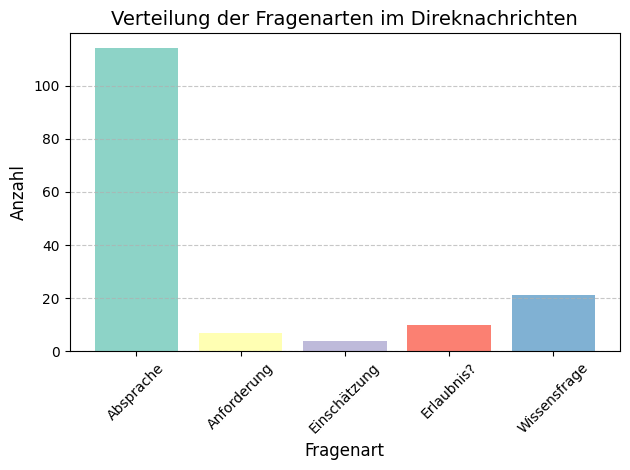

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Daten aus der Tabelle
fragenart = ["Absprache", "Anforderung",
             "Einschätzung", "Erlaubnis?", "Wissensfrage"]
anzahl = [114, 7, 4, 10, 21]

# Farbpalette für Kategorien
colors = sns.color_palette("Set3", len(fragenart))

# Balkendiagramm mit farbiger Kategorisierung
plt.bar(fragenart, anzahl, color=colors)
plt.title("Verteilung der Fragenarten im Direknachrichten", fontsize=14)
plt.xlabel("Fragenart", fontsize=12)
plt.ylabel("Anzahl", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  # Optimiert die Platzierung der Elemente
plt.show()

#### Vorverarbeitung <br>
Stoppwörter entfernen, Lemmatisieren und Stemming, Tokenisierung

In [9]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# NLTK-Resourcen herunterladen
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# Vorverarbeitung


def preprocess(text):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('german'))
    # Nur Buchstaben behalten
    text = re.sub(r'[^a-zA-ZäöüÄÖÜß]', ' ', text)
    # Tokenisierung und Lemmatisierung
    tokens = nltk.word_tokenize(text.lower())
    tokens = [lemmatizer.lemmatize(word)
              for word in tokens if word not in stop_words]
    return " ".join(tokens)


# Preprocessing auf die Fragen anwenden
fragen_preprocessed = [preprocess(frage[1]) for frage in fragen]

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sayeghjs\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sayeghjs\AppData\Roaming\nltk_data...
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sayeghjs\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### Vectorisieren der Fragen

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(fragen_preprocessed)  # Matrix der Vektoren

#### Visualisierung der Cluster UMAP aus (aus der TF-IDF-Matrix X) 

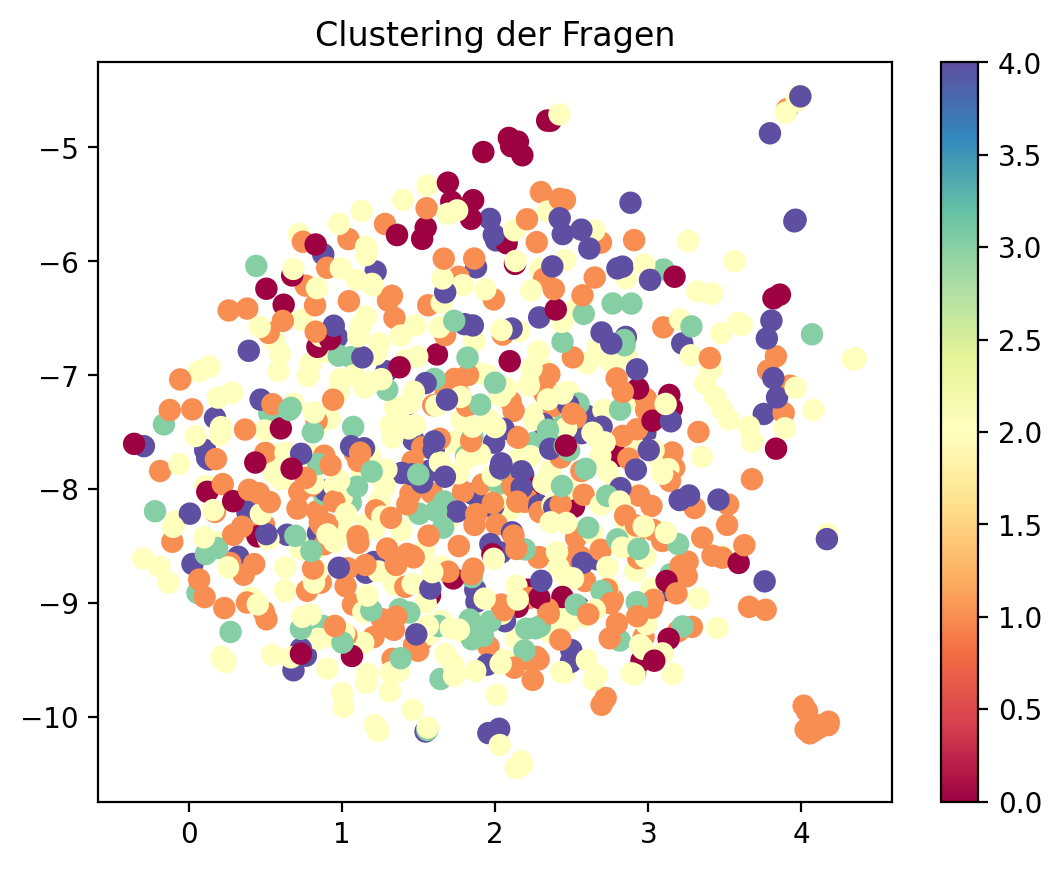

In [19]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

# UMAP-Reduktion
reducer = umap.UMAP()
X_embedded = reducer.fit_transform(X.toarray())

# Plot
plt.scatter(X_embedded[:, 0], X_embedded[:, 1],
            c=labels, cmap='Spectral', s=50)
plt.colorbar()
plt.title("Clustering der Fragen")
plt.show()

### Clustering mit K-Means

In [11]:
from sklearn.cluster import KMeans

num_clusters = 5  # Anzahl der Themen
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X)

# Cluster-Zuweisungen
labels = kmeans.labels_

# Ergebnisse anzeigen
for i, label in enumerate(labels):
    print(f"Frage: {fragen[i][1]} → Cluster {label}")

C:\Users\sayeghjs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Frage: Hallo  Ich wollte dich kurz vorwarnen  dass es evtl zu Konflikten zw den  en in Zimmer 5 kommen könnte aufgrund der Religionsunterschiede   PatName  hat sich gerade darüber aufgeregt dass   PatName  im Zimmer betet bis jetzt geht er immer raus wenn es dazu kommt aber es hat Konfliktpotential → Cluster 1
Frage: Hallo  Vorname das Troponin von  PatName  liegt wieder bei 33 also mehr oder weniger idem zur aufnahme dann leiten wir vorerst keine weiteren schritte ein oder? würde das ganze heute abend den gastros jedoch übergeben  damit sie bescheid wissen → Cluster 2
Frage: liebe  Vorname kannst du mir vielleicht nochmal verraten wer für unsere PhysmedKonsile macht? → Cluster 2
Frage: hi  Vorname unsere neuaufnahme von gestern frau  PatName  berichtet von zunehmendem gedächtnisverlust Sie habe wohl auch einmalig ihren sohn nicht erkannt Dachte vielleicht könnte eine der praktikantinnen einen MiniMental Test oder ähnliches mit ihr machen? → Cluster 1
Frage: hey  Vorname danke für Dein

C:\Users\sayeghjs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\sayeghjs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


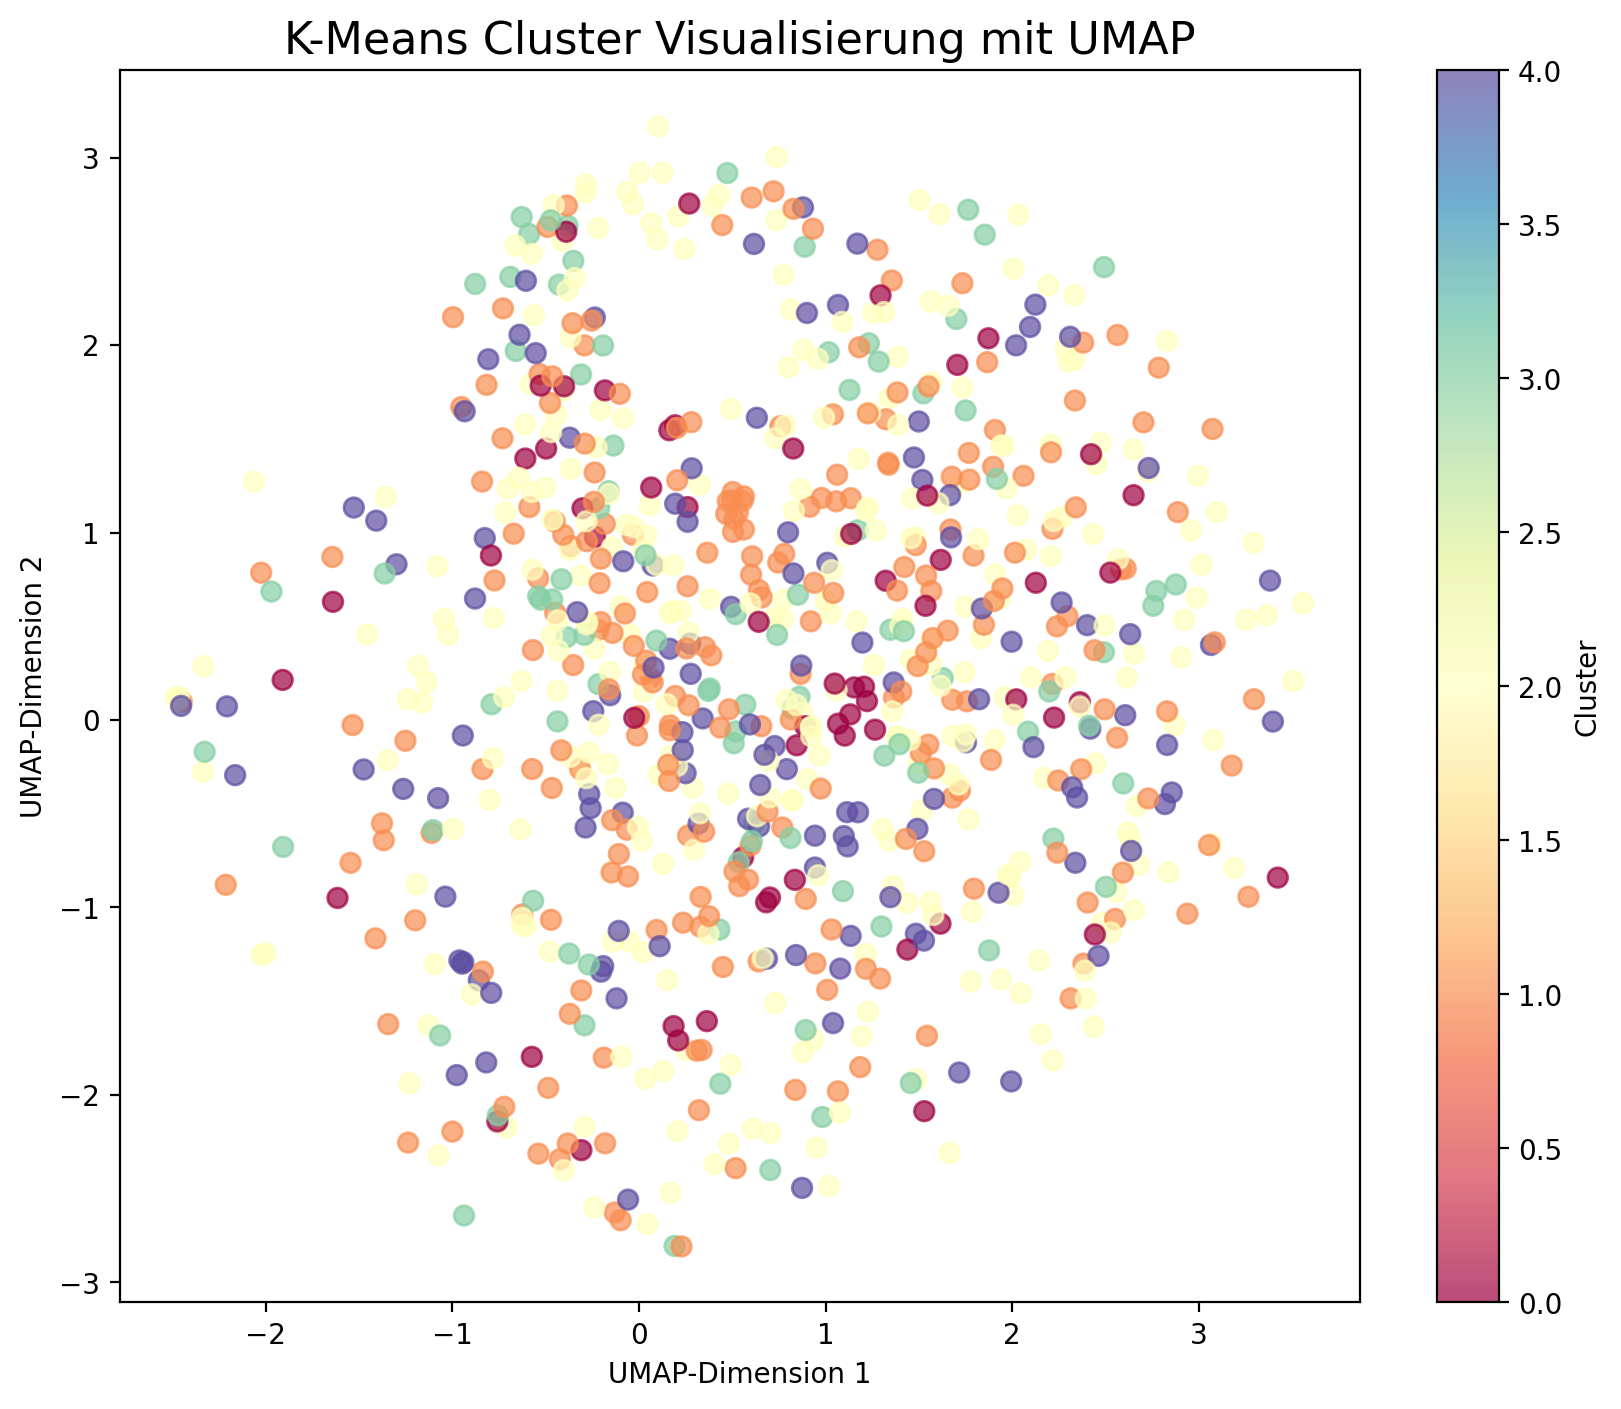

In [16]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Anzahl der Cluster
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X)

# Cluster-Zuweisungen
labels = kmeans.labels_

# Dimensionsreduktion mit UMAP
reducer = umap.UMAP(random_state=42)
X_embedded = reducer.fit_transform(X.toarray())

# Visualisierung der Cluster
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1],
                      c=labels, cmap='Spectral', s=50, alpha=0.7)
plt.colorbar(scatter, label="Cluster")
plt.title("K-Means Cluster Visualisierung mit UMAP", fontsize=16)
plt.xlabel("UMAP-Dimension 1")
plt.ylabel("UMAP-Dimension 2")
plt.show()

### Clustering mit HDBSCAN

In [20]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=10)
labels = clusterer.fit_predict(X)

for i, label in enumerate(labels):
    print(f"Frage: {fragen[i][1]} → Cluster {label}")

Frage: Hallo  Ich wollte dich kurz vorwarnen  dass es evtl zu Konflikten zw den  en in Zimmer 5 kommen könnte aufgrund der Religionsunterschiede   PatName  hat sich gerade darüber aufgeregt dass   PatName  im Zimmer betet bis jetzt geht er immer raus wenn es dazu kommt aber es hat Konfliktpotential → Cluster -1
Frage: Hallo  Vorname das Troponin von  PatName  liegt wieder bei 33 also mehr oder weniger idem zur aufnahme dann leiten wir vorerst keine weiteren schritte ein oder? würde das ganze heute abend den gastros jedoch übergeben  damit sie bescheid wissen → Cluster -1
Frage: liebe  Vorname kannst du mir vielleicht nochmal verraten wer für unsere PhysmedKonsile macht? → Cluster -1
Frage: hi  Vorname unsere neuaufnahme von gestern frau  PatName  berichtet von zunehmendem gedächtnisverlust Sie habe wohl auch einmalig ihren sohn nicht erkannt Dachte vielleicht könnte eine der praktikantinnen einen MiniMental Test oder ähnliches mit ihr machen? → Cluster -1
Frage: hey  Vorname danke für 

In [21]:
from collections import Counter

cluster_keywords = {}
for cluster_id in set(labels):
    cluster_texts = [fragen[i][1]
                     for i in range(len(labels)) if labels[i] == cluster_id]
    all_words = preprocess(" ".join(cluster_texts)).split()
    cluster_keywords[cluster_id] = Counter(all_words).most_common(5)

for cluster, keywords in cluster_keywords.items():
    print(f"Cluster {cluster}: {keywords}")

Cluster -1: [('patname', 720), ('vorname', 386), ('ja', 149), ('morgen', 147), ('mal', 145)]


Code für die Visualisierung der HDBSCAN-Cluster

C:\Users\sayeghjs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


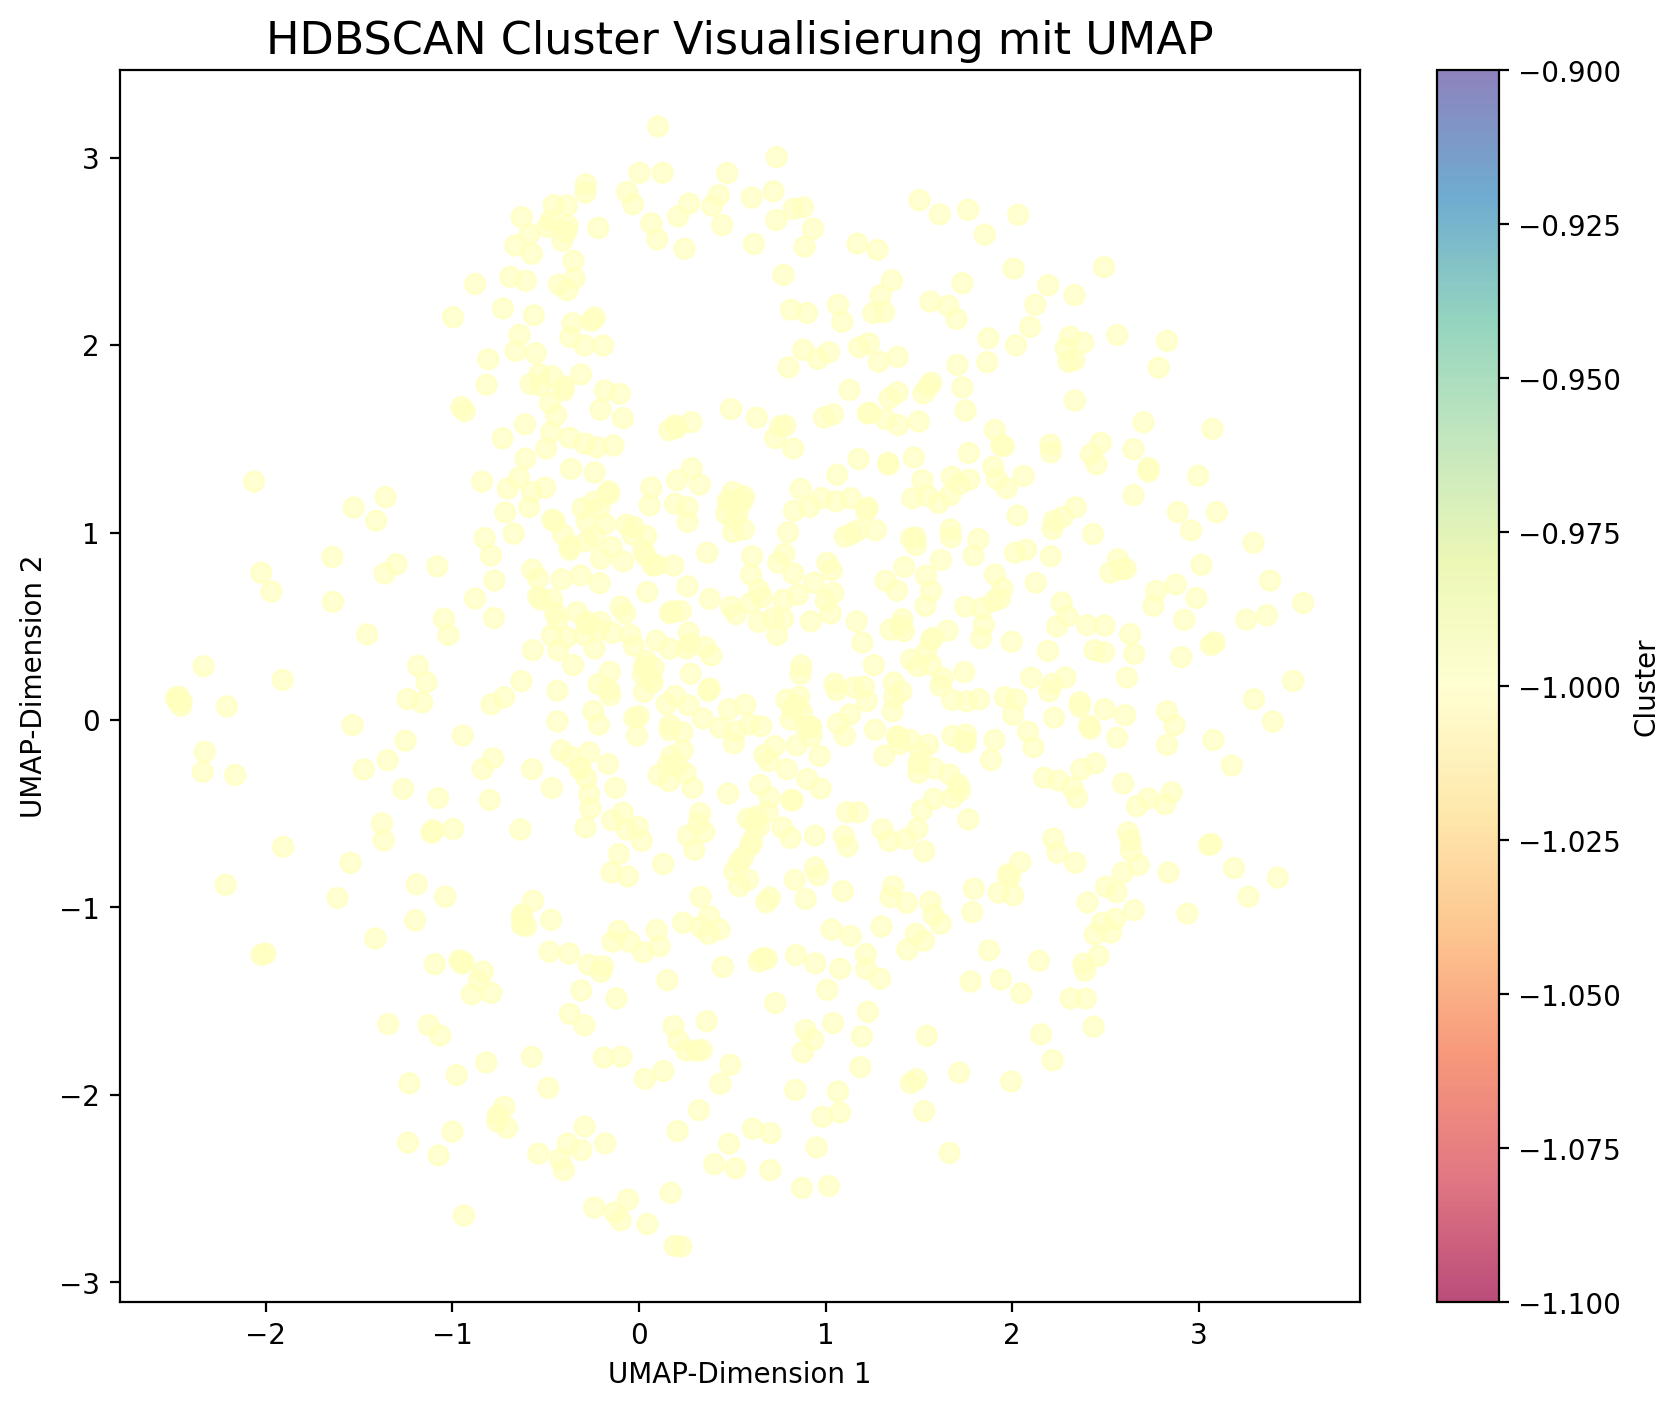

Cluster-Verteilung:
Cluster -1: 839 Punkte


In [22]:
import umap.umap_ as umap
import matplotlib.pyplot as plt
import numpy as np

# UMAP zur Dimensionsreduktion
reducer = umap.UMAP(random_state=42)
# Konvertiere Sparse-Matrix in Dense-Matrix, falls nötig
X_embedded = reducer.fit_transform(X.toarray())

# Visualisierung der Cluster
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_embedded[:, 0], X_embedded[:, 1],
    c=labels,  # Farbcode basierend auf Cluster-Zuweisungen
    cmap='Spectral',  # Farbskala
    s=50,  # Punktgröße
    alpha=0.7  # Transparenz
)

# Farblegende hinzufügen
plt.colorbar(scatter, label="Cluster")
plt.title("HDBSCAN Cluster Visualisierung mit UMAP", fontsize=16)
plt.xlabel("UMAP-Dimension 1")
plt.ylabel("UMAP-Dimension 2")
plt.show()

# Zusätzliche Cluster-Statistik
unique, counts = np.unique(labels, return_counts=True)
print("Cluster-Verteilung:")
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} Punkte")

# -----------------------------------------------------------------

# Semmantik Embedding und dichtebasiertes Clustering der Fragen

## 1. Text-Embeddings mit SentenceTransformers

In [23]:
from sentence_transformers import SentenceTransformer

# Vortrainiertes Embedding-Modell laden
model = SentenceTransformer('distiluse-base-multilingual-cased-v1')

# Semantische Embeddings der Fragen erstellen
fragen_embedded = model.encode([frage[1] for frage in fragen])

C:\Users\sayeghjs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\sayeghjs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sentence_transformers\models\Dense.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`.

## 2. Clustering mit HDBSCAN

In [33]:
import hdbscan

# HDBSCAN-Cluster erstellen
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5, min_samples=3, metric='euclidean')
labels = clusterer.fit_predict(fragen_embedded)

# Cluster-Zuweisungen ausgeben
for i, label in enumerate(labels):
    print(f"Frage: {fragen[i][1]} → Cluster {label}")

Frage: Hallo  Ich wollte dich kurz vorwarnen  dass es evtl zu Konflikten zw den  en in Zimmer 5 kommen könnte aufgrund der Religionsunterschiede   PatName  hat sich gerade darüber aufgeregt dass   PatName  im Zimmer betet bis jetzt geht er immer raus wenn es dazu kommt aber es hat Konfliktpotential → Cluster -1
Frage: Hallo  Vorname das Troponin von  PatName  liegt wieder bei 33 also mehr oder weniger idem zur aufnahme dann leiten wir vorerst keine weiteren schritte ein oder? würde das ganze heute abend den gastros jedoch übergeben  damit sie bescheid wissen → Cluster -1
Frage: liebe  Vorname kannst du mir vielleicht nochmal verraten wer für unsere PhysmedKonsile macht? → Cluster 1
Frage: hi  Vorname unsere neuaufnahme von gestern frau  PatName  berichtet von zunehmendem gedächtnisverlust Sie habe wohl auch einmalig ihren sohn nicht erkannt Dachte vielleicht könnte eine der praktikantinnen einen MiniMental Test oder ähnliches mit ihr machen? → Cluster -1
Frage: hey  Vorname danke für D

## 3. Visualisierung der Cluster

C:\Users\sayeghjs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


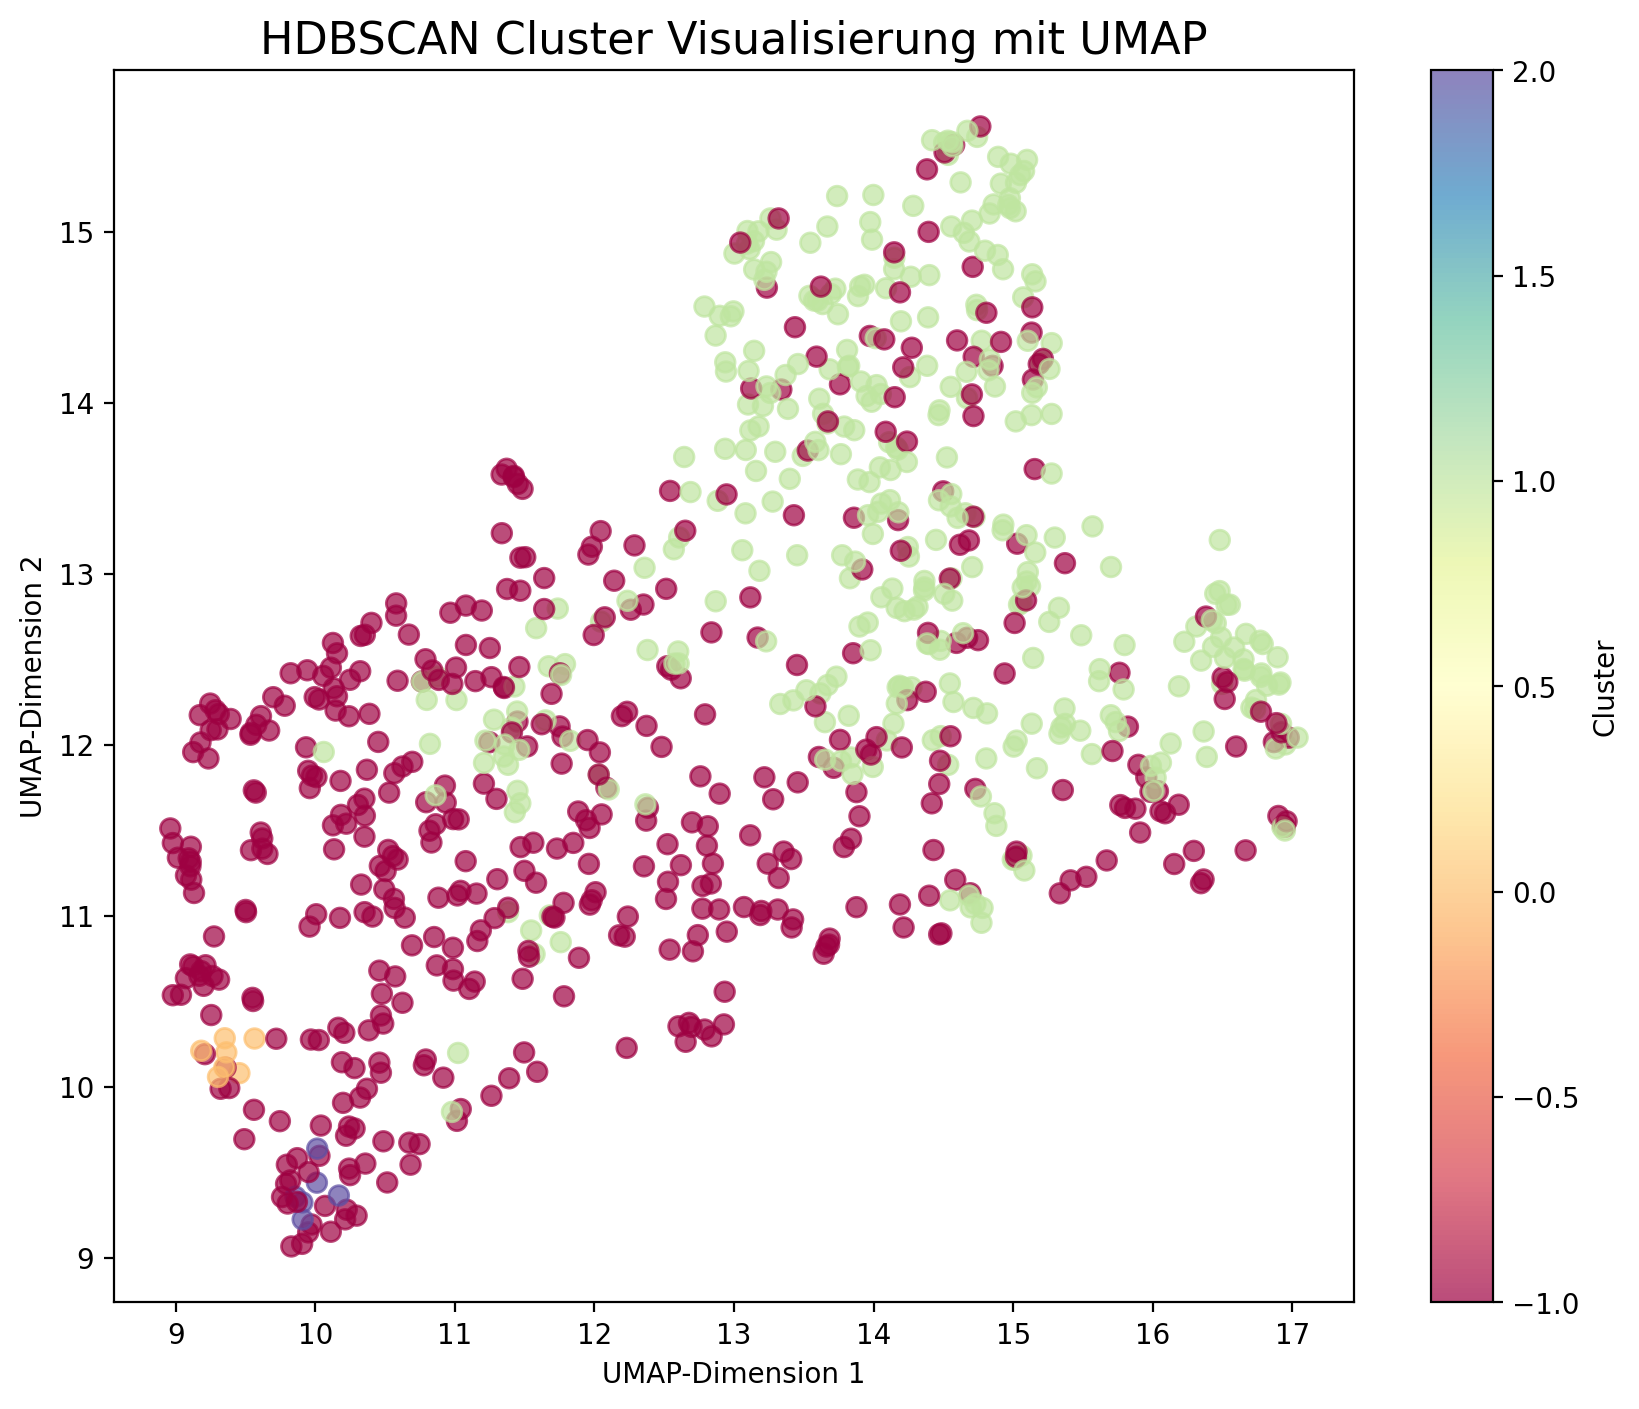

In [34]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

# UMAP-Reduktion
reducer = umap.UMAP(random_state=42)
fragen_2d = reducer.fit_transform(fragen_embedded)

# Visualisierung der Cluster
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    fragen_2d[:, 0], fragen_2d[:, 1], c=labels, cmap='Spectral', s=50, alpha=0.7)
plt.colorbar(scatter, label="Cluster")
plt.title("HDBSCAN Cluster Visualisierung mit UMAP", fontsize=16)
plt.xlabel("UMAP-Dimension 1")
plt.ylabel("UMAP-Dimension 2")
plt.show()

## 4. Schlüsselwörter pro Cluster analysieren

In [36]:
from collections import Counter

cluster_keywords = {}
for cluster_id in set(labels):
    if cluster_id == -1:  # Überspringe Rauschen (-1)
        continue
    cluster_texts = [fragen[i][1]
                     for i in range(len(labels)) if labels[i] == cluster_id]
    all_words = " ".join(cluster_texts).split()
    cluster_keywords[cluster_id] = Counter(all_words).most_common(10)

# Schlüsselwörter pro Cluster anzeigen
for cluster, keywords in cluster_keywords.items():
    print(f"Cluster {cluster}: {keywords}")

Cluster 0: [('es', 6), ('Wie', 4), ('mit', 4), ('Guten', 3), ('aus?', 3), ('Morgen!', 2), ('sieht', 2), ('du', 2), ('wie', 2), ('Mittag', 2)]
Cluster 1: [('PatName', 582), ('und', 346), ('ich', 331), ('sie', 305), ('Vorname', 291), ('die', 276), ('mit', 238), ('der', 216), ('in', 201), ('das', 190)]
Cluster 2: [('wie', 3), ('Wie', 2), ('sieht', 2), ('es', 2), ('bei', 2), ('dir?', 2), ('siehst', 1), ('du', 1), ('das?', 1), ('aus?', 1)]
